# Experiment 5: Implement a flow-based generative model using a deep learning framework.


Epoch 0, Loss: 3.7134
Epoch 100, Loss: 1.5107
Epoch 200, Loss: 1.0854
Epoch 300, Loss: 0.8555
Epoch 400, Loss: 0.8337
Epoch 500, Loss: 0.8626
Epoch 600, Loss: 0.7807
Epoch 700, Loss: 0.8467
Epoch 800, Loss: 0.8022
Epoch 900, Loss: 0.7958


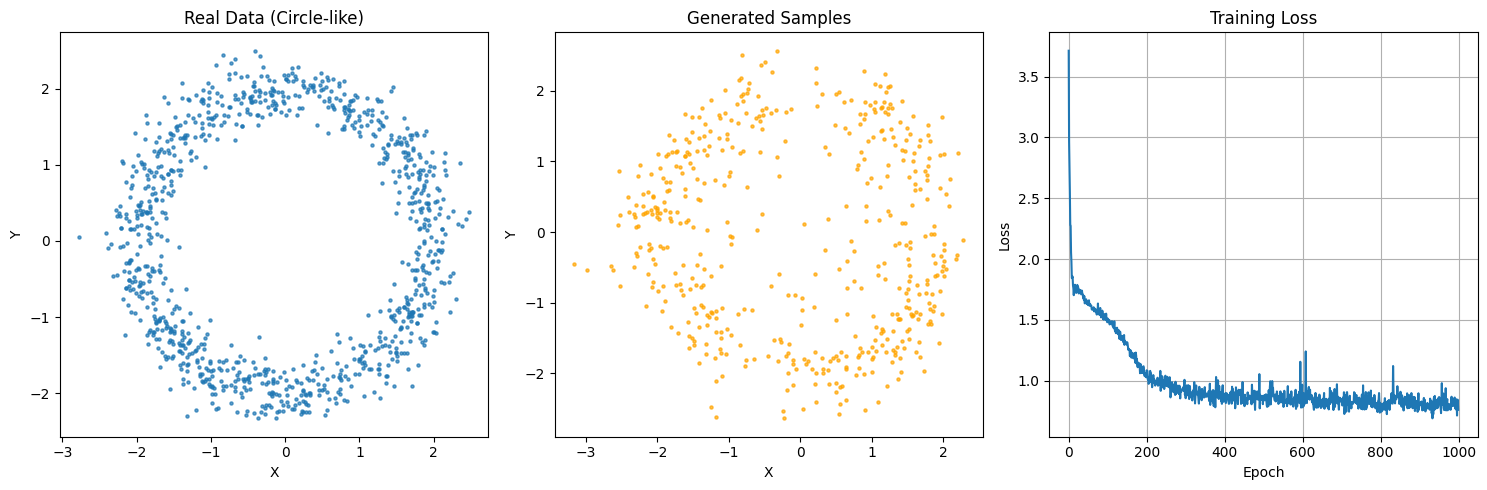

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# -------- Coupling Layer --------
class CouplingLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim // 2, 64),
            nn.ReLU(),
            nn.Linear(64, dim)
        )

    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        h = self.net(x1)
        s, t = h.chunk(2, dim=1)
        s = torch.tanh(s)

        y2 = x2 * torch.exp(s) + t
        return torch.cat([x1, y2], dim=1), s.sum(dim=1)

    def inverse(self, y):
        y1, y2 = y.chunk(2, dim=1)
        h = self.net(y1)
        s, t = h.chunk(2, dim=1)
        s = torch.tanh(s)

        x2 = (y2 - t) * torch.exp(-s)
        return torch.cat([y1, x2], dim=1)

# -------- RealNVP Model --------
class RealNVP(nn.Module):
    def __init__(self, dim, num_layers=4):
        super().__init__()
        self.layers = nn.ModuleList([CouplingLayer(dim) for _ in range(num_layers)])

    def forward(self, x):
        log_det = 0
        for layer in self.layers:
            x, ld = layer(x)
            log_det += ld
            x = x.flip(dims=[1])  # simple permutation
        return x, log_det

    def inverse(self, z):
        for layer in reversed(self.layers):
            z = z.flip(dims=[1])
            z = layer.inverse(z)
        return z

# -------- Loss Function --------
def loss_fn(z, log_det):
    log_prob = -0.5 * torch.sum(z**2, dim=1)
    return -(log_prob + log_det).mean()

# -------- Training --------
model = RealNVP(dim=2)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Toy data (2D circle-like)
def sample_data(n):
    theta = torch.rand(n) * 2 * 3.14
    r = 2 + 0.2 * torch.randn(n)
    x = r * torch.cos(theta)
    y = r * torch.sin(theta)
    return torch.stack([x, y], dim=1)

# Store losses for plotting
losses_history = []
real_data_samples = sample_data(1000) # Generate a larger set of real data for plotting

# Train loop
for epoch in range(1000):
    x_batch = sample_data(256)
    z, log_det = model(x_batch)

    loss = loss_fn(z, log_det)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# -------- Sampling --------
with torch.no_grad():
    z = torch.randn(500, 2)  # Gaussian noise
    generated_samples = model.inverse(z)

# Plot generated samples, real data, and loss
generated_samples = generated_samples.numpy()

plt.figure(figsize=(15, 5))

# Plot Real Data
plt.subplot(1, 3, 1)
plt.scatter(real_data_samples[:, 0], real_data_samples[:, 1], s=5, alpha=0.7)
plt.title("Real Data (Circle-like)")
plt.xlabel("X"); plt.ylabel("Y")

# Plot Generated Samples
plt.subplot(1, 3, 2)
plt.scatter(generated_samples[:, 0], generated_samples[:, 1], s=5, alpha=0.7, color='orange')
plt.title("Generated Samples")
plt.xlabel("X"); plt.ylabel("Y")

# Plot Training Loss
plt.subplot(1, 3, 3)
plt.plot(losses_history)
plt.title("Training Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()